# Presentación de los datos de España

En este notebook, analizaremos los datos de España. Los datos proceden del **Instituto Nacional de Estadística (INE)**, disponibles en su web https://www.ine.es/.

Se han extraido los siguientes datos:
* Actividad Física
* Asistencia a Eventos
* Calidad del Aire
* Índice de criminalidad
* Rango de edades
* Nivel de educación
* Estado civil
* Horas Trabajadas al mes
* Población
* Salario bruto anual
* Satisfacción servicios sanitarios
* Género de la población

Si hubiera más de una serie temporal de datos en alguna de las categorías, se ha seleccionado la serie más reciente disponible.

In [1]:
# Importación de librerías y configuración básica
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

data_basepath = '..\\data\\spain_original_data\\'
img_basepath = '.\\img\\'

## Población

En él se muestra la población total de España, desglosada por cada comunidad autónoma.
Las cifras son las oficiales de población resultantes de la revisión del Padrón municipal de la serie más reciente disponible.

In [2]:
df_population = pd.read_csv(f'{data_basepath}poblacion_por_comunidad.csv', sep=';')
df_population

,comunidad_autonoma,poblacion
0,Andalucía,8472407
1,Aragón,1326261
2,Asturias. Principado de,1011792
3,Balears. Illes,1173008
4,Canarias,2172944
5,Cantabria,584507
6,Castilla y León,2383139
7,Castilla - La Mancha,2049562
8,Cataluña,7763362
9,Comunitat Valenciana,5058138


Total de población en España: 47,385,107


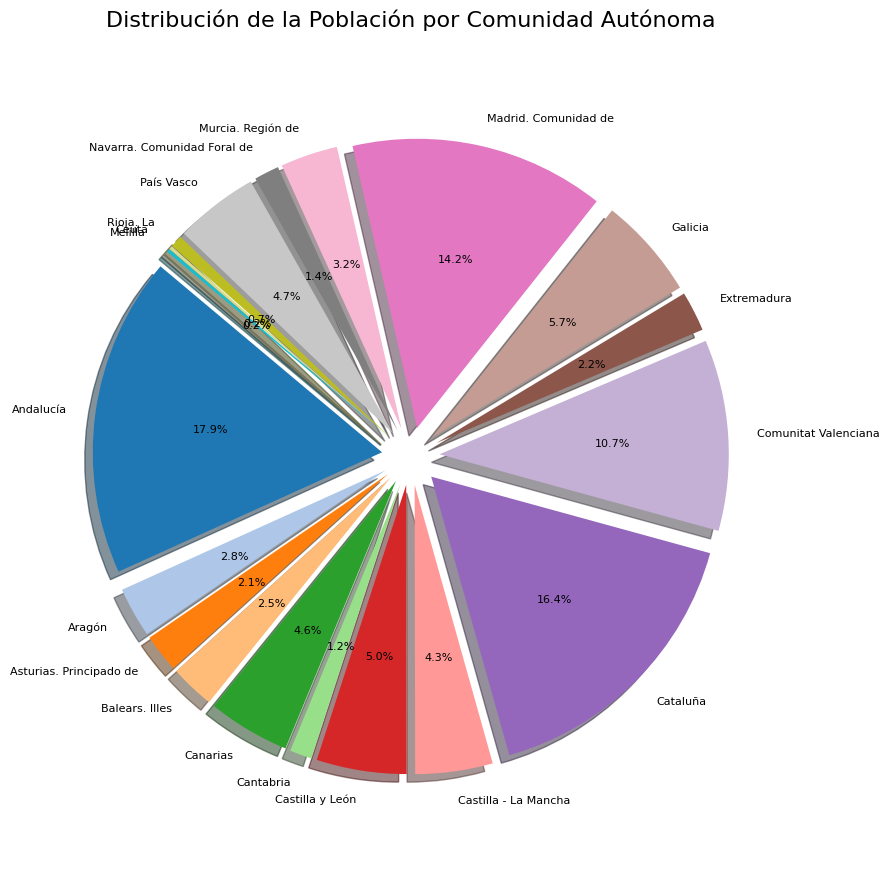

In [3]:
# Calcula el total de población
total_population = df_population['poblacion'].sum()
print(f'Total de población en España: {total_population:,}')

# Calcula los porcentajes de población por comunidad
df_population['porcentaje'] = (df_population['poblacion'] / total_population) * 100

# Define los colores para las comunidades para mejor lectura
df_population['colors'] = sns.color_palette('tab20', len(df_population))

# Crea la gráfica
plt.figure(figsize=(9, 9))
plt.pie(df_population['poblacion'], labels=df_population['comunidad_autonoma'],
        colors=df_population['colors'], autopct='%1.1f%%', startangle=140, shadow=True,
        explode=[0.1]*len(df_population), textprops={'fontsize': 8})
plt.title(f'Distribución de la Población por Comunidad Autónoma', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{img_basepath}01_01_poblacion_por_comunidad.png', dpi=300, bbox_inches='tight')
plt.show()

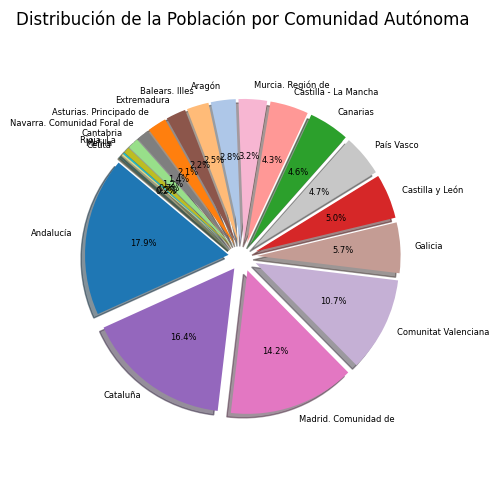

In [4]:
# La misma gráfica, ordenada por porcentaje de población
df_population_ordered = df_population.sort_values(by='porcentaje', ascending=False)
plt.figure(figsize=(5, 5))
plt.pie(df_population_ordered['porcentaje'], labels=df_population_ordered['comunidad_autonoma'],
        colors=df_population_ordered['colors'], autopct='%1.1f%%', startangle=140, shadow=True,
        explode=[0.1]*len(df_population_ordered), textprops={'fontsize': 6})
plt.title('Distribución de la Población por Comunidad Autónoma', fontsize=12)
plt.axis('equal')
plt.tight_layout()
plt.savefig(f'{img_basepath}01_02_poblacion_por_comunidad.png', dpi=300, bbox_inches='tight')
plt.show()

## Actividad Física

Se separa la actividad física en tres categorías: Nivel alto, moderado y bajo. El nivel alto se refiere a personas que realizan actividad física de forma regular, el nivel moderado a personas que realizan actividad física ocasionalmente y el nivel bajo a personas que no realizan actividad física.

Los datos vienen expresados en porcentaje de la población total de la comunidad autónoma.

In [5]:
df_sportActivity = pd.read_csv(f'{data_basepath}actividadFisica_por_comunidad.csv', sep=';')
df_sportActivity

,comunidad_autonoma,nivel_alto,nivel_moderado,nivel_bajo
0,Andalucía,20.22,36.95,42.83
1,Aragón,10.94,44.69,44.37
2,Asturias. Principado de,18.14,49.78,32.08
3,Balears. Illes,20.46,44.19,35.34
4,Canarias,27.02,26.34,46.64
5,Cantabria,9.15,56.65,34.19
6,Castilla y León,24.42,41.95,33.63
7,Castilla - La Mancha,25.90,38.07,36.04
8,Cataluña,18.02,32.73,49.25
9,Comunitat Valenciana,40.01,38.49,21.50


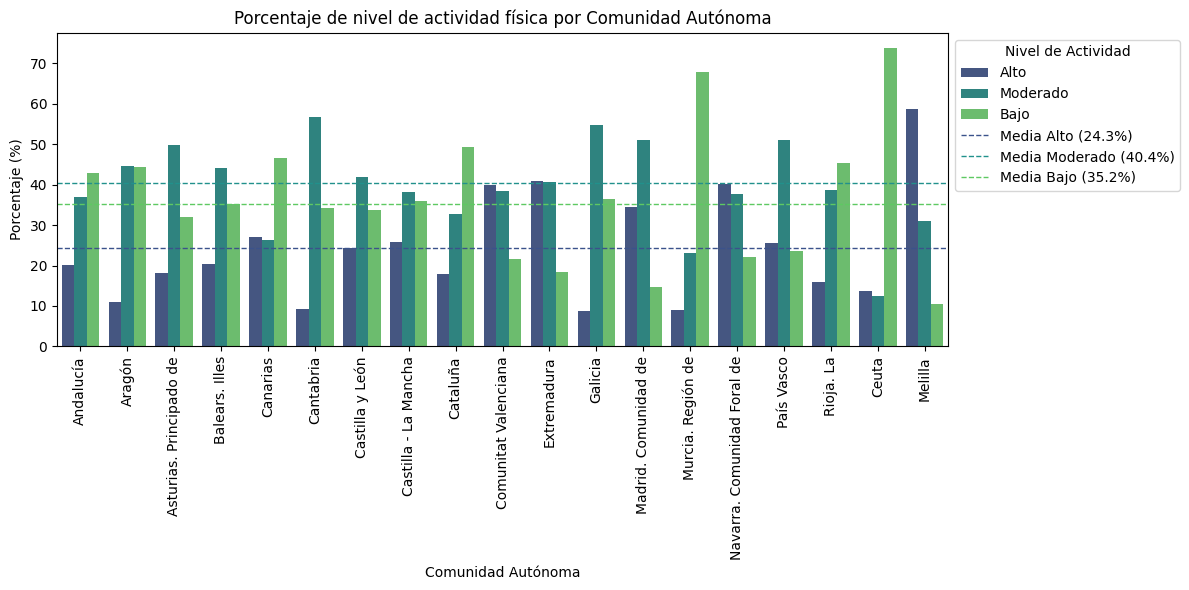

In [6]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_sportActivity, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_nivel_alto = (df_merged['nivel_alto'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_nivel_moderado = (df_merged['nivel_moderado'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_nivel_bajo = (df_merged['nivel_bajo'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# # Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
# mean_nivel_alto = df_sportActivity['nivel_alto'].mean()
# mean_nivel_moderado = df_sportActivity['nivel_moderado'].mean()
# mean_nivel_bajo = df_sportActivity['nivel_bajo'].mean()

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'Alto': sns.color_palette('viridis', 3)[0],
    'Moderado': sns.color_palette('viridis', 3)[1],
    'Bajo': sns.color_palette('viridis', 3)[2]
}

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_sportActivity_melted = df_sportActivity.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['nivel_alto', 'nivel_moderado', 'nivel_bajo'],
    var_name='nivel_deporte',
    value_name='Porcentaje'
)

# Renombra los valores para mejor lectura
df_sportActivity_melted['nivel_deporte'] = df_sportActivity_melted['nivel_deporte'].map({
    'nivel_alto': 'Alto',
    'nivel_moderado': 'Moderado',
    'nivel_bajo': 'Bajo'
})

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_sportActivity_melted,
    x='comunidad_autonoma',
    y='Porcentaje',
    hue='nivel_deporte',
    palette='viridis'
)

plt.axhline(mean_nivel_alto, color=colores_lineas['Alto'], linestyle='--', linewidth=1, label=f'Media Alto ({mean_nivel_alto:.1f}%)')
plt.axhline(mean_nivel_moderado, color=colores_lineas['Moderado'], linestyle='--', linewidth=1, label=f'Media Moderado ({mean_nivel_moderado:.1f}%)')
plt.axhline(mean_nivel_bajo, color=colores_lineas['Bajo'], linestyle='--', linewidth=1, label=f'Media Bajo ({mean_nivel_bajo:.1f}%)')

plt.title('Porcentaje de nivel de actividad física por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Nivel de Actividad', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}02_01_actividad_fisica.png', dpi=300, bbox_inches='tight')
plt.show()

## Asistencia a eventos

Porcentaje de asistencia a eventos culturales, deportivos o lugares de interés cultural a los que han asistido en los últimos doce meses, CCAA, número de veces en el año 2022 (últimos datos recogidos).

Se distingue entre si han asistido a estos eventos, si no han asistido por falta de interés, o si no han asistido aún queriendo asistir por falta de tiempo o recursos.

In [7]:
df_eventsAttendance = pd.read_csv(f'{data_basepath}asistenciaAEventos_por_comunidad.csv', sep=';')
df_eventsAttendance

,comunidad_autonoma,cine_si,cine_no_puede,cine_no,directos_si,directos_no_puede,directos_no,culturales_si,culturales_no_puede,culturales_no,deportivos_si,deportivos_no_puede,deportivos_no
0,Andalucía,32.7,11.3,56.0,28.0,14.9,57.1,33.7,11.8,54.5,21.6,10.2,68.2
1,Aragón,38.7,5.5,55.8,33.1,8.9,58.1,45.4,6.3,48.3,29.8,4.6,65.6
2,Asturias. Principado de,29.5,4.6,65.9,28.8,5.8,65.4,38.5,3.5,58.1,27.3,3.0,69.7
3,Balears. Illes,34.9,7.0,58.1,29.8,9.7,60.6,37.7,7.3,55.0,27.3,6.5,66.2
4,Canarias,28.1,9.1,62.8,23.0,13.0,64.0,26.5,10.2,63.3,22.5,6.6,70.8
5,Cantabria,34.8,5.3,59.9,28.7,7.8,63.5,39.1,6.2,54.6,29.6,3.9,66.5
6,Castilla y León,31.4,5.2,63.4,31.8,8.3,59.9,41.5,5.9,52.5,23.6,4.6,71.8
7,Castilla - La Mancha,33.6,8.6,57.8,32.1,11.7,56.2,36.5,9.0,54.5,23.7,8.2,68.1
8,Cataluña,41.4,7.7,51.0,37.1,11.5,51.4,42.0,8.1,49.9,25.6,7.2,67.1
9,Comunitat Valenciana,36.7,6.8,56.5,31.3,10.1,58.6,37.5,8.0,54.5,22.5,6.7,70.8


### Cine

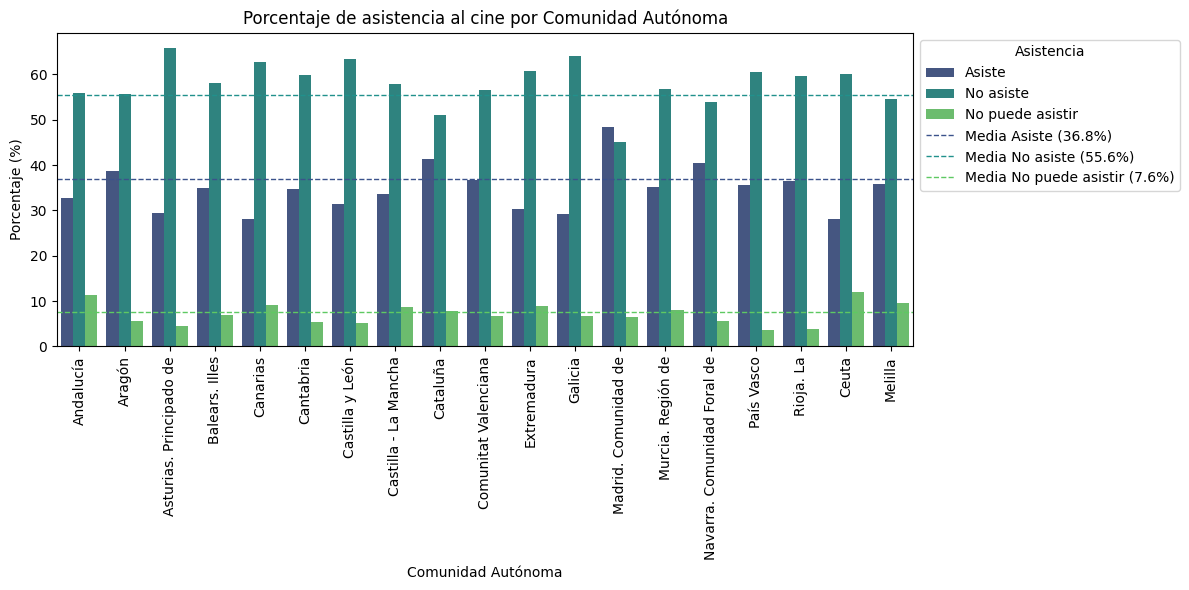

In [8]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_eventsAttendance, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_cine_si = (df_merged['cine_si'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_cine_no = (df_merged['cine_no'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_cine_no_puede = (df_merged['cine_no_puede'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()


# # Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
# mean_cine_si = df_eventsAttendance['cine_si'].mean()
# mean_cine_no = df_eventsAttendance['cine_no'].mean()
# mean_cine_no_puede = df_eventsAttendance['cine_no_puede'].mean()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_cinemaAttendance_melted = df_eventsAttendance.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['cine_si', 'cine_no', 'cine_no_puede'],
    var_name='cine_asistencia',
    value_name='Porcentaje'
)

# Renombra los valores para mejor lectura
df_cinemaAttendance_melted['cine_asistencia'] = df_cinemaAttendance_melted['cine_asistencia'].map({
    'cine_si': 'Asiste',
    'cine_no': 'No asiste',
    'cine_no_puede': 'No puede asistir'
})

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'Asiste': sns.color_palette('viridis', 3)[0],
    'No asiste': sns.color_palette('viridis', 3)[1],
    'No puede asistir': sns.color_palette('viridis', 3)[2]
}

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_cinemaAttendance_melted,
    x='comunidad_autonoma',
    y='Porcentaje',
    hue='cine_asistencia',
    palette='viridis'
)

plt.axhline(mean_cine_si, color=colores_lineas['Asiste'], linestyle='--', linewidth=1, label=f'Media Asiste ({mean_cine_si:.1f}%)')
plt.axhline(mean_cine_no, color=colores_lineas['No asiste'], linestyle='--', linewidth=1, label=f'Media No asiste ({mean_cine_no:.1f}%)')
plt.axhline(mean_cine_no_puede, color=colores_lineas['No puede asistir'], linestyle='--', linewidth=1, label=f'Media No puede asistir ({mean_cine_no_puede:.1f}%)')

plt.title('Porcentaje de asistencia al cine por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Asistencia', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}03_01_asistencia_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

### Directos

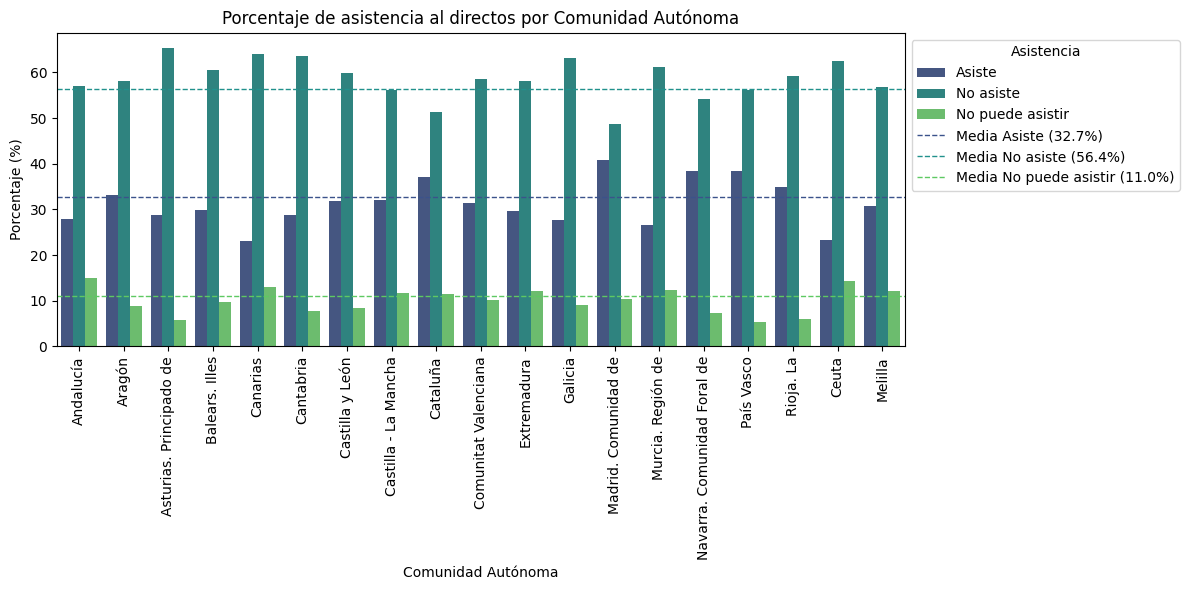

In [9]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_eventsAttendance, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_directos_si = (df_merged['directos_si'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_directos_no = (df_merged['directos_no'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_directos_no_puede = (df_merged['directos_no_puede'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# # Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
# mean_directos_si = df_eventsAttendance['directos_si'].mean()
# mean_directos_no = df_eventsAttendance['directos_no'].mean()
# mean_directos_no_puede = df_eventsAttendance['directos_no_puede'].mean()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_directsAttendance_melted = df_eventsAttendance.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['directos_si', 'directos_no', 'directos_no_puede'],
    var_name='directos_asistencia',
    value_name='Porcentaje'
)

# Renombra los valores para mejor lectura
df_directsAttendance_melted['directos_asistencia'] = df_directsAttendance_melted['directos_asistencia'].map({
    'directos_si': 'Asiste',
    'directos_no': 'No asiste',
    'directos_no_puede': 'No puede asistir'
})

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_directsAttendance_melted,
    x='comunidad_autonoma',
    y='Porcentaje',
    hue='directos_asistencia',
    palette='viridis'
)

plt.axhline(mean_directos_si, color=colores_lineas['Asiste'], linestyle='--', linewidth=1, label=f'Media Asiste ({mean_directos_si:.1f}%)')
plt.axhline(mean_directos_no, color=colores_lineas['No asiste'], linestyle='--', linewidth=1, label=f'Media No asiste ({mean_directos_no:.1f}%)')
plt.axhline(mean_directos_no_puede, color=colores_lineas['No puede asistir'], linestyle='--', linewidth=1, label=f'Media No puede asistir ({mean_directos_no_puede:.1f}%)')

plt.title('Porcentaje de asistencia al directos por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Asistencia', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}03_02_asistencia_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

### Eventos culturales

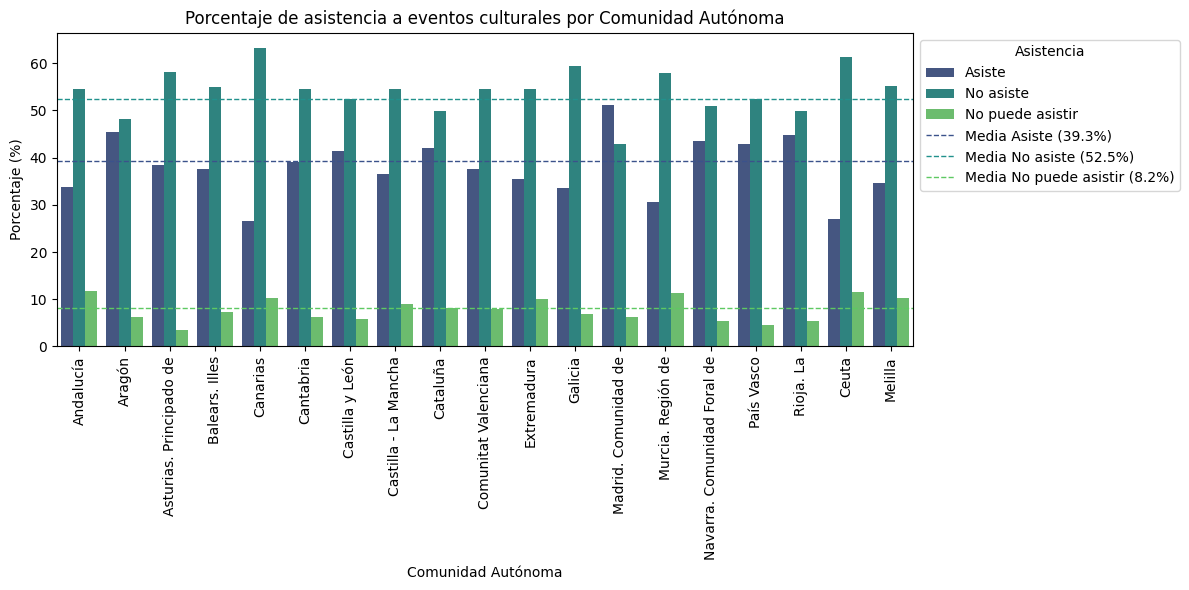

In [10]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_eventsAttendance, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_culturales_si = (df_merged['culturales_si'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_culturales_no = (df_merged['culturales_no'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_culturales_no_puede = (df_merged['culturales_no_puede'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# # Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
# mean_culturales_si = df_eventsAttendance['culturales_si'].mean()
# mean_culturales_no = df_eventsAttendance['culturales_no'].mean()
# mean_culturales_no_puede = df_eventsAttendance['culturales_no_puede'].mean()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_directsAttendance_melted = df_eventsAttendance.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['culturales_si', 'culturales_no', 'culturales_no_puede'],
    var_name='culturales_asistencia',
    value_name='Porcentaje'
)

# Renombra los valores para mejor lectura
df_directsAttendance_melted['culturales_asistencia'] = df_directsAttendance_melted['culturales_asistencia'].map({
    'culturales_si': 'Asiste',
    'culturales_no': 'No asiste',
    'culturales_no_puede': 'No puede asistir'
})

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_directsAttendance_melted,
    x='comunidad_autonoma',
    y='Porcentaje',
    hue='culturales_asistencia',
    palette='viridis'
)

plt.axhline(mean_culturales_si, color=colores_lineas['Asiste'], linestyle='--', linewidth=1, label=f'Media Asiste ({mean_culturales_si:.1f}%)')
plt.axhline(mean_culturales_no, color=colores_lineas['No asiste'], linestyle='--', linewidth=1, label=f'Media No asiste ({mean_culturales_no:.1f}%)')
plt.axhline(mean_culturales_no_puede, color=colores_lineas['No puede asistir'], linestyle='--', linewidth=1, label=f'Media No puede asistir ({mean_culturales_no_puede:.1f}%)')

plt.title('Porcentaje de asistencia a eventos culturales por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Asistencia', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}03_03_asistencia_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

### Eventos deportivos

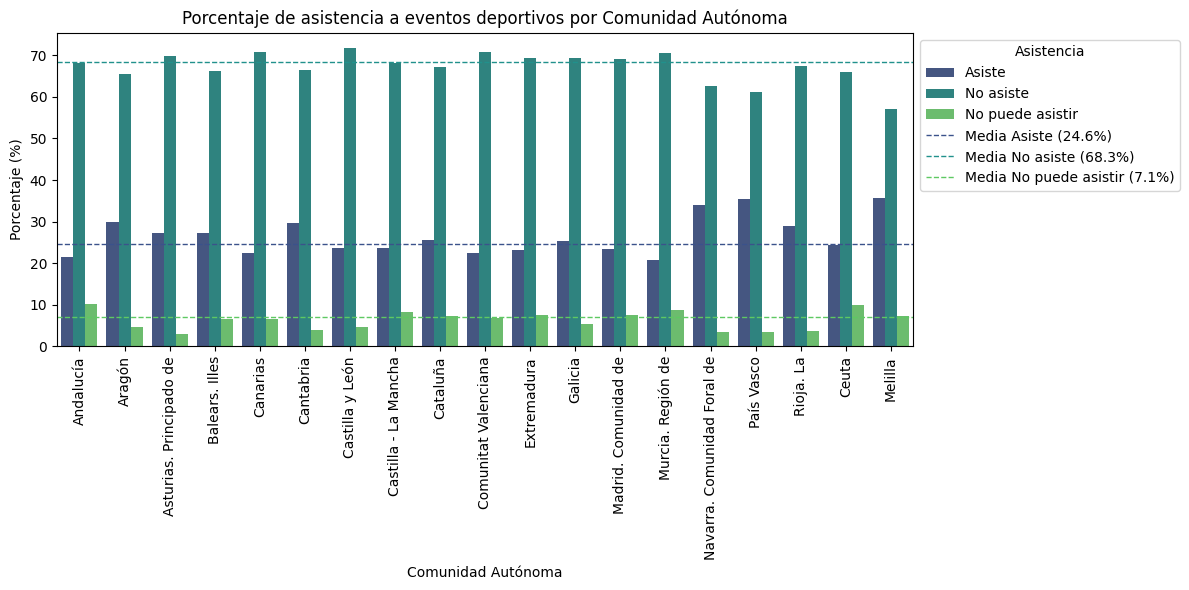

In [11]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_eventsAttendance, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_deportivos_si = (df_merged['deportivos_si'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_deportivos_no = (df_merged['deportivos_no'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_deportivos_no_puede = (df_merged['deportivos_no_puede'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# # Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
# mean_deportivos_si = df_eventsAttendance['deportivos_si'].mean()
# mean_deportivos_no = df_eventsAttendance['deportivos_no'].mean()
# mean_deportivos_no_puede = df_eventsAttendance['deportivos_no_puede'].mean()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_cinemaAttendance_melted = df_eventsAttendance.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['deportivos_si', 'deportivos_no', 'deportivos_no_puede'],
    var_name='deportivos_asistencia',
    value_name='Porcentaje'
)

# Renombra los valores para mejor lectura
df_cinemaAttendance_melted['deportivos_asistencia'] = df_cinemaAttendance_melted['deportivos_asistencia'].map({
    'deportivos_si': 'Asiste',
    'deportivos_no': 'No asiste',
    'deportivos_no_puede': 'No puede asistir'
})

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_cinemaAttendance_melted,
    x='comunidad_autonoma',
    y='Porcentaje',
    hue='deportivos_asistencia',
    palette='viridis'
)

plt.axhline(mean_deportivos_si, color=colores_lineas['Asiste'], linestyle='--', linewidth=1, label=f'Media Asiste ({mean_deportivos_si:.1f}%)')
plt.axhline(mean_deportivos_no, color=colores_lineas['No asiste'], linestyle='--', linewidth=1, label=f'Media No asiste ({mean_deportivos_no:.1f}%)')
plt.axhline(mean_deportivos_no_puede, color=colores_lineas['No puede asistir'], linestyle='--', linewidth=1, label=f'Media No puede asistir ({mean_deportivos_no_puede:.1f}%)')

plt.title('Porcentaje de asistencia a eventos deportivos por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Asistencia', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}03_04_asistencia_eventos.png', dpi=300, bbox_inches='tight')
plt.show()

## Calidad del aire

Media ponderada con la población del número de días al año en que se supera la concentración límite diaria de 50 µg/m3 de PM10 (partículas en suspensión con un diámetro aerodinámico menor o igual a 10 micrómetros), separado por comunidades autónomas.

In [12]:
df_airPollution = pd.read_csv(f'{data_basepath}calidadDelAire_por_comunidad.csv', sep=';')
df_airPollution

,comunidad_autonoma,dias_alta_contaminacion
0,Andalucía,9.45
1,Aragón,7.96
2,Asturias. Principado de,12.22
3,Balears. Illes,3.56
4,Canarias,33.70
5,Cantabria,0.92
6,Castilla y León,2.76
7,Castilla - La Mancha,17.48
8,Cataluña,3.83
9,Comunitat Valenciana,3.60


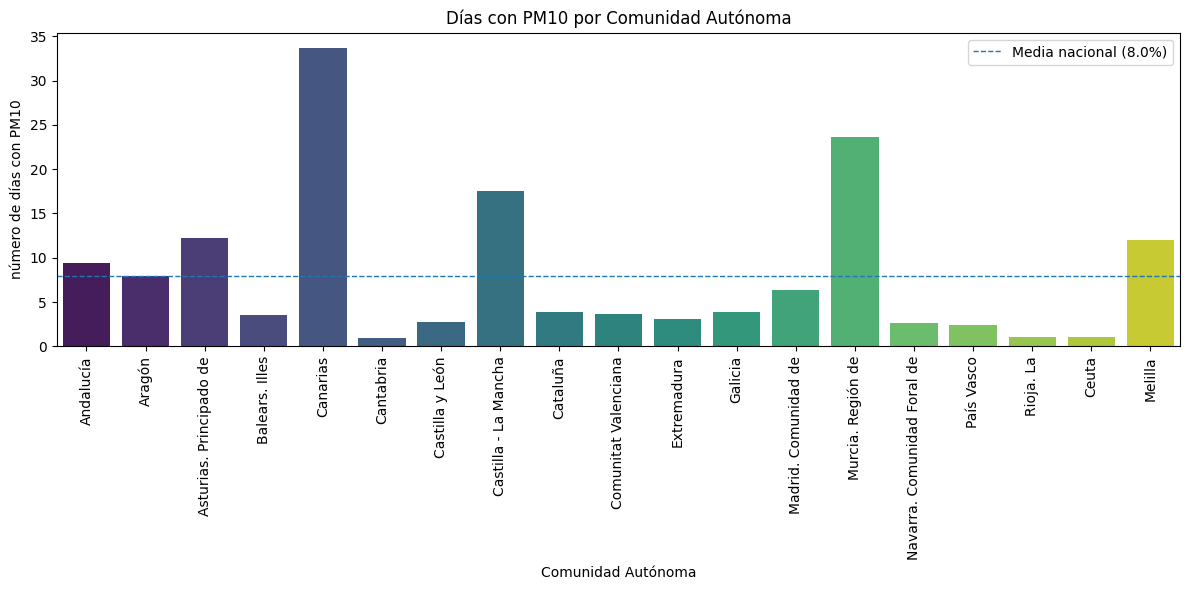

In [13]:
# Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
mean_airPollution = df_airPollution['dias_alta_contaminacion'].mean()

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_airPollution,
    x='comunidad_autonoma',
    y='dias_alta_contaminacion',
    palette='viridis'
)

plt.axhline(mean_airPollution, linestyle='--', linewidth=1, label=f'Media nacional ({mean_airPollution:.1f}%)')

plt.title('Días con PM10 por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('número de días con PM10')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}04_01_calidad_aire.png', dpi=300, bbox_inches='tight')
plt.show()

## Criminalidad

Se muestra el número de homicidios por cada 100.000 habitantes, y el número de crímenes por cada 1.000 habitantes, en cada comunidad autónoma.

Los indicadores objetivos tasa de homicidios y tasa de criminalidad se puede considerar indicadores de contexto, en tanto que no son indicadores directos de cómo la seguridad física se puede medir en las personas afectadas (se recogen datos de los hechos conocidos y no de las víctimas).

In [14]:
df_criminality = pd.read_csv(f'{data_basepath}criminalidad_por_comunidad.csv', sep=';')
df_criminality

,comunidad_autonoma,homicidios_por_100mhabit,criminalidad_por_1000habit
0,Andalucía,0.822030,47.978098
1,Aragón,0.667554,37.770077
2,Asturias. Principado de,0.594025,33.654071
3,Balears. Illes,0.645780,64.139401
4,Canarias,0.756857,46.819254
5,Cantabria,0.000000,41.075370
6,Castilla y León,0.418354,37.637657
7,Castilla - La Mancha,0.711771,39.980952
8,Cataluña,0.880000,63.942554
9,Comunitat Valenciana,0.634410,54.527105


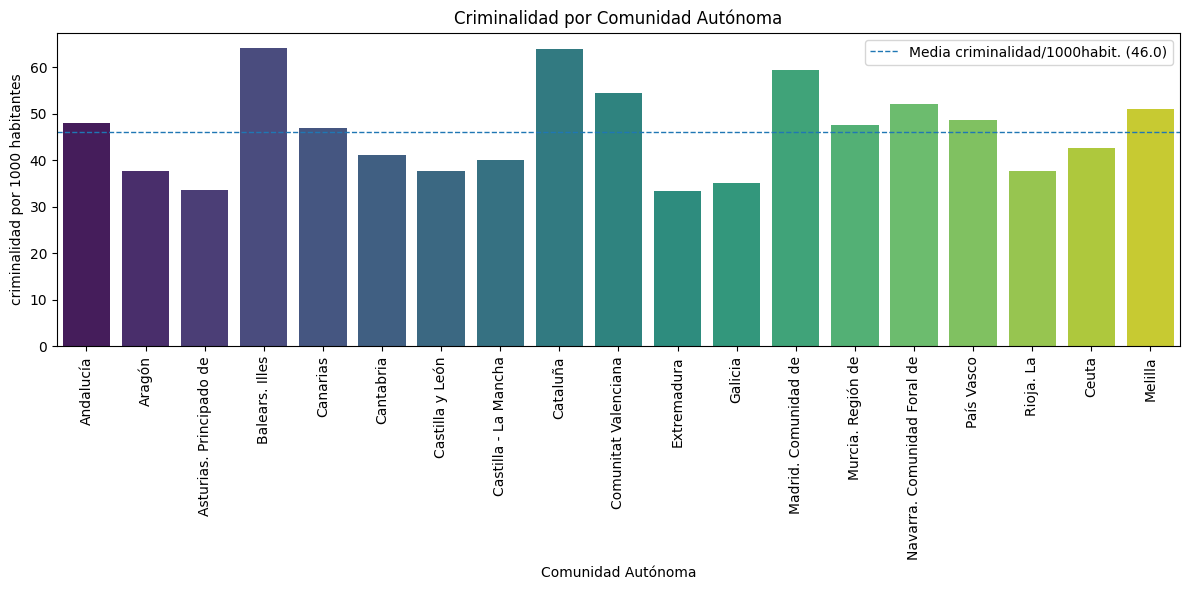

In [15]:
# Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
mean_criminality = df_criminality['criminalidad_por_1000habit'].mean()

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_criminality,
    x='comunidad_autonoma',
    y='criminalidad_por_1000habit',
    palette='viridis'
)

plt.axhline(mean_criminality, linestyle='--', linewidth=1, label=f'Media criminalidad/1000habit. ({mean_criminality:.1f})')

plt.title('Criminalidad por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('criminalidad por 1000 habitantes')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}05_01_criminalidad.png', dpi=300, bbox_inches='tight')
plt.show()

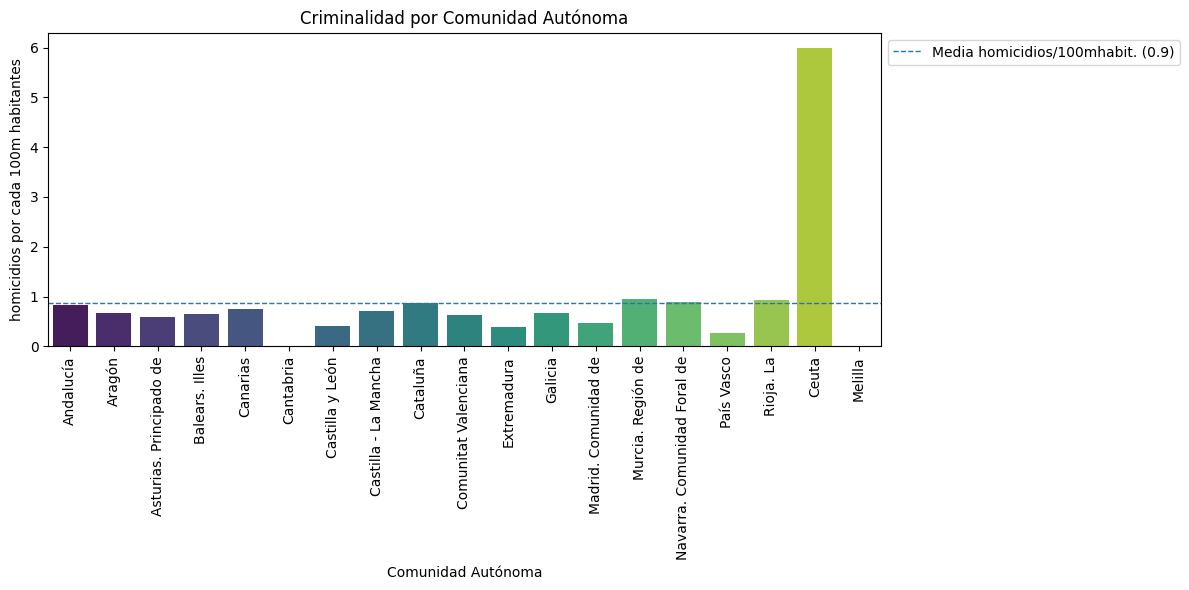

In [16]:
# Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
mean_homicides = df_criminality['homicidios_por_100mhabit'].mean()

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_criminality,
    x='comunidad_autonoma',
    y='homicidios_por_100mhabit',
    palette='viridis'
)

plt.axhline(mean_homicides, linestyle='--', linewidth=1, label=f'Media homicidios/100mhabit. ({mean_homicides:.1f})')

plt.title('Criminalidad por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('homicidios por cada 100m habitantes')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}05_02_criminalidad.png', dpi=300, bbox_inches='tight')
plt.show()

## Edad

Rango de edad de la población, desglosado por cada comunidad autónoma. Se muestra la población total que se encuentra en cada rango de edad.

In [17]:
df_age = pd.read_csv(f'{data_basepath}edades_por_comunidad.csv', sep=';')
df_age

,comunidad_autonoma,0-4_anos,5-9_anos,10-14_anos,15-19_anos,20-24_anos,25-29_anos,30-34_anos,35-39_anos,40-44_anos,...,55-59_anos,60-64_anos,65-69_anos,70-74_anos,75-79_anos,80-84_anos,85-89_anos,90-94_anos,95-99_anos,100-110_anos
0,Andalucía,345555,423786,484477,477131,453539,468002,511105,577191,683756,...,633113,547955,438137,367290,301419,200271,144390,59384,13172,2925
1,Aragón,49782,61253,67610,65311,64832,66442,71681,82576,102772,...,98729,89733,74669,65322,55970,38918,35213,17595,4559,688
2,Asturias. Principado de,27021,35383,41670,40379,38823,38904,44785,58462,77593,...,80773,81245,72662,63599,51379,33460,31394,15568,4108,686
3,Balears. Illes,49246,57466,62293,60567,62032,71554,82078,90451,102842,...,81491,68470,55921,47553,37543,23807,17379,7733,2022,327
4,Canarias,70074,89912,104627,113425,119019,128943,141041,153551,181074,...,175673,140070,113101,91583,72734,45620,33106,12940,3013,770
5,Cantabria,18780,24625,29112,28342,25770,25282,28772,36337,47721,...,44900,43801,37234,32303,24500,16553,14730,7393,2034,318
6,Castilla y León,71922,92799,104905,104619,104599,104524,113729,136025,170221,...,191966,182409,153172,133966,116110,85092,78685,41110,12082,1884
7,Castilla - La Mancha,79665,101137,113688,110219,108732,109462,118307,135324,163807,...,153535,135624,102525,88054,72720,55276,47033,23242,5802,855
8,Cataluña,310576,380332,428860,419813,409002,436769,471798,522814,637313,...,538142,471359,399794,356451,292278,196845,158718,75057,19816,2836
9,Comunitat Valenciana,191146,240500,276521,270720,258579,263282,285632,329604,415622,...,375698,335542,280503,248588,200662,139243,95850,41695,10093,1587


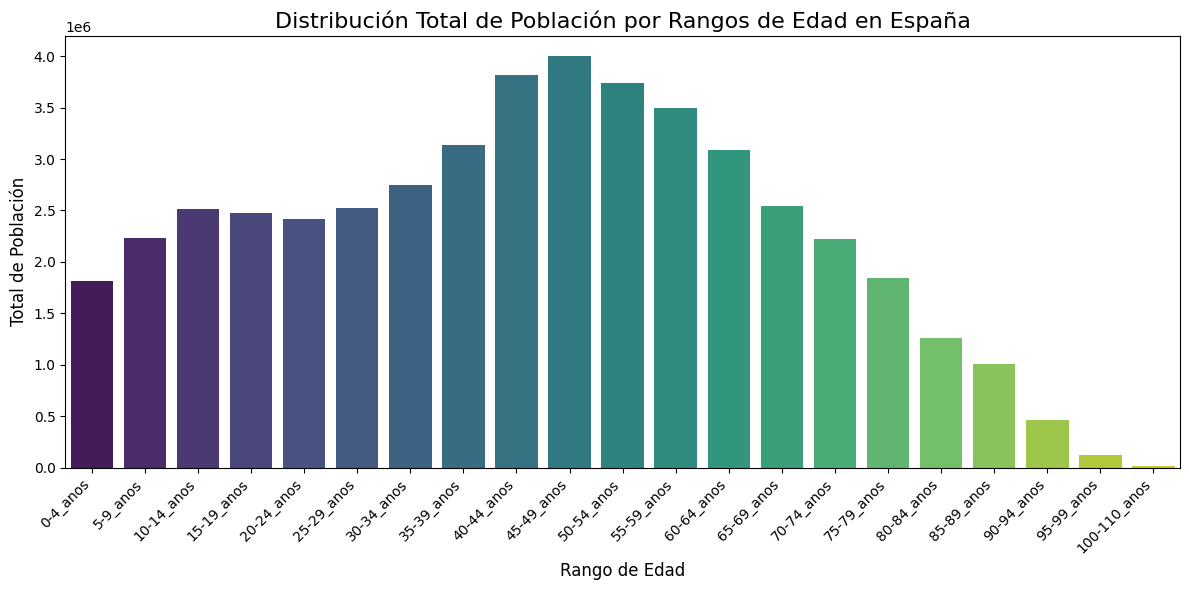

In [18]:
# Sumar todos los valores numéricos de las columnas para cada fila, excluyendo 'comunidad_autonoma'
total_row = df_age.select_dtypes(include=np.number).sum().to_dict()

# Añadir la columna 'comunidad_autonoma' con el valor 'TOTAL'
total_row['comunidad_autonoma'] = 'TOTAL'

# Convertir el diccionario a un DataFrame de una sola fila
df_total = pd.DataFrame([total_row])

# Concatenar el nuevo DataFrame al final del original
df_ages = pd.concat([df_age, df_total], ignore_index=True)

# Extraer la fila 'TOTAL'
df_total_ages = df_ages[df_ages['comunidad_autonoma'] == 'TOTAL']

# Transponer el DataFrame para que las columnas de edades sean filas
# Eliminar la columna 'comunidad_autonoma' antes de transponer
df_total_ages_transposed = df_total_ages.drop('comunidad_autonoma', axis=1).T

# Resetear el índice para que los nombres de las edades se conviertan en una columna
df_total_ages_transposed = df_total_ages_transposed.reset_index()

# Renombrar las columnas
df_total_ages_transposed.columns = ['Rango_Edad', 'Total']

# Crear la gráfica de barras
plt.figure(figsize=(12, 6)) # Ajustar el tamaño de la figura
sns.barplot(x='Rango_Edad', y='Total', data=df_total_ages_transposed, palette='viridis')

# Añadir título y etiquetas
plt.title('Distribución Total de Población por Rangos de Edad en España', fontsize=16)
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Total de Población', fontsize=12)

# Rotar las etiquetas del eje x si son largas para evitar solapamiento
plt.xticks(rotation=45, ha='right')

# Asegurar que el layout se ajusta para mostrar todas las etiquetas
plt.tight_layout()

plt.savefig(f'{img_basepath}06_01_edades.png', dpi=300, bbox_inches='tight')

# Mostrar la gráfica
plt.show()

## Nivel de estudios

Se muestra el nivel de estudios alcanzado por la población, desglosado por cada comunidad autónoma. Se muestran los porcentajes de la población que ha alcanzado cada nivel de estudios indicado en cada caso.

In [19]:
df_educationLevel = pd.read_csv(f'{data_basepath}educacion_por_comunidad.csv', sep=';')
df_educationLevel

,comunidad_autonoma,total,analfabetos,estudios_primarios_incompletos,primaria,primero_secundaria,segundo_secundaria_general,segundo_secundaria_profesional,educacion_superior
0,Andalucía,100,2.1,6.6,9.9,30.6,12.9,8.5,29.5
1,Aragón,100,0.5,2.5,12.1,28.6,12.5,10.5,33.3
2,Asturias. Principado de,100,0.3,1.7,8.7,31.6,14.4,9.3,34.1
3,Balears. Illes,100,1.2,2.7,11.9,30.0,16.9,9.2,28.0
4,Canarias,100,1.3,4.8,11.4,25.9,18.4,8.7,29.6
5,Cantabria,100,0.3,0.3,7.1,28.4,13.3,11.0,39.5
6,Castilla y León,100,0.5,2.9,13.6,28.6,13.4,9.2,31.7
7,Castilla - La Mancha,100,1.1,6.9,11.3,33.5,12.9,8.4,25.9
8,Cataluña,100,1.0,3.2,11.9,26.0,13.5,8.3,36.2
9,Comunitat Valenciana,100,1.3,4.4,8.0,33.3,12.0,10.3,30.8


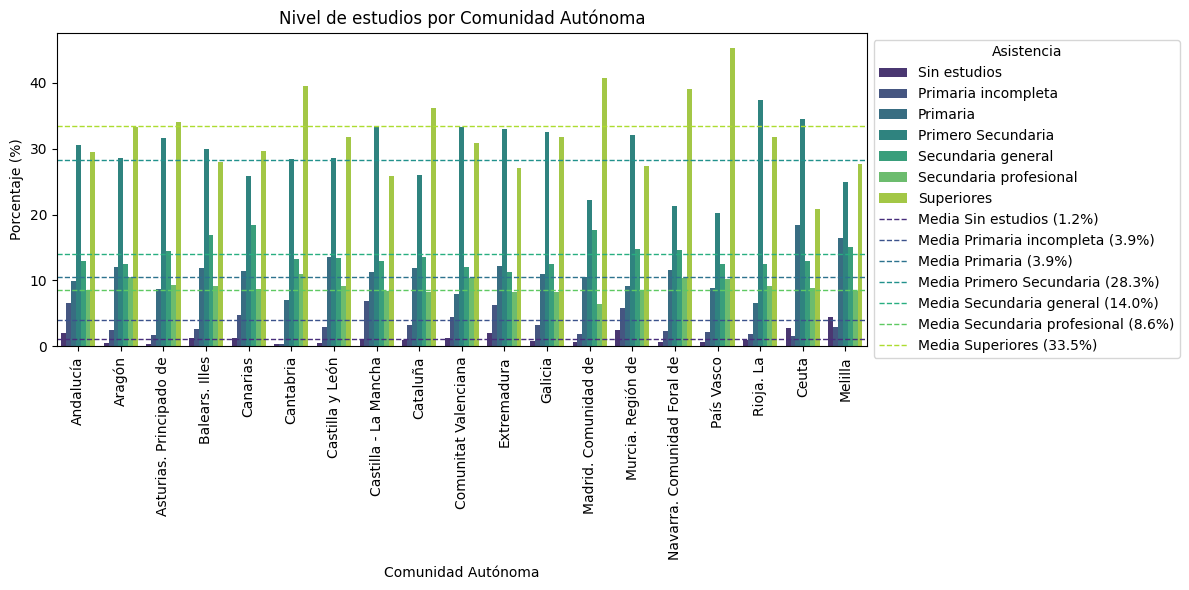

In [20]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_educationLevel, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_analfabetos = (df_merged['analfabetos'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_estudios_primarios_incompletos = (df_merged['estudios_primarios_incompletos'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_primaria = (df_merged['primaria'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_primero_secundaria = (df_merged['primero_secundaria'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_segundo_secundaria_general = (df_merged['segundo_secundaria_general'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_segundo_secundaria_profesional = (df_merged['segundo_secundaria_profesional'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_educacion_superior = (df_merged['educacion_superior'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()


# # Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
# mean_analfabetos = df_educationLevel['analfabetos'].mean()
# mean_estudios_primarios_incompletos = df_educationLevel['estudios_primarios_incompletos'].mean()
# mean_primaria = df_educationLevel['primaria'].mean()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_educationLevel_melted = df_educationLevel.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['analfabetos',
                'estudios_primarios_incompletos',
                'primaria',
                'primero_secundaria',
                'segundo_secundaria_general',
                'segundo_secundaria_profesional',
                'educacion_superior'],
    var_name='nivel_educacion',
    value_name='Porcentaje'
)

# Renombra los valores para mejor lectura
df_educationLevel_melted['nivel_educacion'] = df_educationLevel_melted['nivel_educacion'].map({
    'analfabetos': 'Sin estudios',
    'estudios_primarios_incompletos': 'Primaria incompleta',
    'primaria': 'Primaria',
    'primero_secundaria': 'Primero Secundaria',
    'segundo_secundaria_general': 'Secundaria general',
    'segundo_secundaria_profesional': 'Secundaria profesional',
    'educacion_superior': 'Superiores'
})

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'Sin estudios': sns.color_palette('viridis', 7)[0],
    'Primaria incompleta': sns.color_palette('viridis', 7)[1],
    'Primaria': sns.color_palette('viridis', 7)[2],
    'Primero Secundaria': sns.color_palette('viridis', 7)[3],
    'Secundaria general': sns.color_palette('viridis', 7)[4],
    'Secundaria profesional': sns.color_palette('viridis', 7)[5],
    'Superiores': sns.color_palette('viridis', 7)[6]
}

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_educationLevel_melted,
    x='comunidad_autonoma',
    y='Porcentaje',
    hue='nivel_educacion',
    palette='viridis'
)

plt.axhline(mean_analfabetos, color=colores_lineas['Sin estudios'], linestyle='--', linewidth=1, label=f'Media Sin estudios ({mean_analfabetos:.1f}%)')
plt.axhline(mean_estudios_primarios_incompletos, color=colores_lineas['Primaria incompleta'], linestyle='--', linewidth=1, label=f'Media Primaria incompleta ({mean_estudios_primarios_incompletos:.1f}%)')
plt.axhline(mean_primaria, color=colores_lineas['Primaria'], linestyle='--', linewidth=1, label=f'Media Primaria ({mean_estudios_primarios_incompletos:.1f}%)')
plt.axhline(mean_primero_secundaria, color=colores_lineas['Primero Secundaria'], linestyle='--', linewidth=1, label=f'Media Primero Secundaria ({mean_primero_secundaria:.1f}%)')
plt.axhline(mean_segundo_secundaria_general, color=colores_lineas['Secundaria general'], linestyle='--', linewidth=1, label=f'Media Secundaria general ({mean_segundo_secundaria_general:.1f}%)')
plt.axhline(mean_segundo_secundaria_profesional, color=colores_lineas['Secundaria profesional'], linestyle='--', linewidth=1, label=f'Media Secundaria profesional ({mean_segundo_secundaria_profesional:.1f}%)')
plt.axhline(mean_educacion_superior, color=colores_lineas['Superiores'], linestyle='--', linewidth=1, label=f'Media Superiores ({mean_educacion_superior:.1f}%)')

plt.title('Nivel de estudios por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Asistencia', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}07_01_estudios.png', dpi=300, bbox_inches='tight')
plt.show()

## Estado civil

Se muestra el estado civil de la población, desglosado por cada comunidad autónoma. Se muestran la población mayor de 16 años que se encuentra en cada estado civil.

In [21]:
df_maritalStatus = pd.read_csv(f'{data_basepath}estadoCivil_por_comunidad.csv', sep=';')
df_maritalStatus

,comunidad_autonoma,total,soltero/a,casado/a,viudo/a,separado/a,divorciado/a
0,Andalucía,8419.9,3871.4,3597.5,472.1,122.9,355.8
1,Aragón,1306.7,581.9,575.6,81.6,17.1,50.6
2,Asturias. Principado de,1004.2,407.7,446.5,88.0,20.8,41.2
3,Balears. Illes,1207.3,601.8,474.3,57.4,16.8,57.0
4,Canarias,2229.9,1124.7,782.6,125.1,39.7,157.8
5,Cantabria,576.0,254.3,252.1,36.9,8.6,24.0
6,Castilla y León,2337.6,992.9,1042.5,170.6,31.4,100.2
7,Castilla - La Mancha,2012.6,903.2,887.1,119.6,23.2,79.4
8,Cataluña,7570.0,3530.9,3044.3,448.8,116.9,429.0
9,Comunitat Valenciana,4997.4,2198.6,2147.7,311.6,70.4,269.0


In [22]:
# Creamos unas columnas adicionales con el % por comunidad
df_maritalStatus['porcentaje_casados'] = (df_maritalStatus['casado/a'] / df_maritalStatus['total']) * 100
df_maritalStatus['porcentaje_solteros'] = (df_maritalStatus['soltero/a'] / df_maritalStatus['total']) * 100
df_maritalStatus['porcentaje_viudos'] = (df_maritalStatus['viudo/a'] / df_maritalStatus['total']) * 100
df_maritalStatus['porcentaje_separados'] = (df_maritalStatus['separado/a'] / df_maritalStatus['total']) * 100
df_maritalStatus['porcentaje_divorciados'] = (df_maritalStatus['divorciado/a'] / df_maritalStatus['total']) * 100
df_maritalStatus

,comunidad_autonoma,total,soltero/a,casado/a,viudo/a,separado/a,divorciado/a,porcentaje_casados,porcentaje_solteros,porcentaje_viudos,porcentaje_separados,porcentaje_divorciados
0,Andalucía,8419.9,3871.4,3597.5,472.1,122.9,355.8,42.726161,45.979168,5.606955,1.459637,4.225703
1,Aragón,1306.7,581.9,575.6,81.6,17.1,50.6,44.049897,44.532027,6.244739,1.308640,3.872350
2,Asturias. Principado de,1004.2,407.7,446.5,88.0,20.8,41.2,44.463254,40.599482,8.763195,2.071301,4.102768
3,Balears. Illes,1207.3,601.8,474.3,57.4,16.8,57.0,39.286010,49.846766,4.754411,1.391535,4.721279
4,Canarias,2229.9,1124.7,782.6,125.1,39.7,157.8,35.095744,50.437239,5.610117,1.780349,7.076551
5,Cantabria,576.0,254.3,252.1,36.9,8.6,24.0,43.767361,44.149306,6.406250,1.493056,4.166667
6,Castilla y León,2337.6,992.9,1042.5,170.6,31.4,100.2,44.597023,42.475188,7.298084,1.343258,4.286448
7,Castilla - La Mancha,2012.6,903.2,887.1,119.6,23.2,79.4,44.077313,44.877273,5.942562,1.152738,3.945146
8,Cataluña,7570.0,3530.9,3044.3,448.8,116.9,429.0,40.215324,46.643329,5.928666,1.544254,5.667107
9,Comunitat Valenciana,4997.4,2198.6,2147.7,311.6,70.4,269.0,42.976348,43.994877,6.235242,1.408733,5.382799


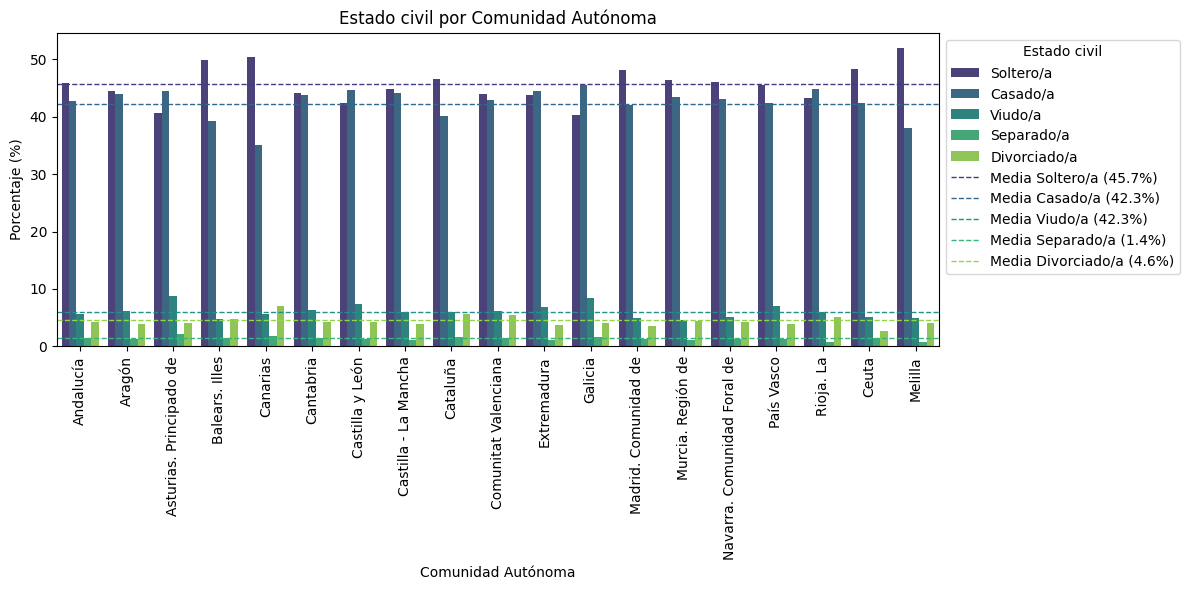

In [23]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_maritalStatus, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_soltero = (df_merged['porcentaje_solteros'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_casado = (df_merged['porcentaje_casados'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_viudo = (df_merged['porcentaje_viudos'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_separado = (df_merged['porcentaje_separados'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_divorciado = (df_merged['porcentaje_divorciados'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# # Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
# mean_soltero = df_maritalStatus['soltero/a'].mean()
# mean_casado = df_maritalStatus['casado/a'].mean()
# mean_viudo = df_maritalStatus['viudo/a'].mean()
# mean_separado = df_maritalStatus['separado/a'].mean()
# mean_divorciado = df_maritalStatus['divorciado/a'].mean()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_maritalStatus_melted = df_maritalStatus.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['porcentaje_solteros',
                'porcentaje_casados',
                'porcentaje_viudos',
                'porcentaje_separados',
                'porcentaje_divorciados'],
    var_name='estado_civil',
    value_name='estado'
)

# Renombra los valores para mejor lectura
df_maritalStatus_melted['estado_civil'] = df_maritalStatus_melted['estado_civil'].map({
    'porcentaje_solteros': 'Soltero/a',
    'porcentaje_casados': 'Casado/a',
    'porcentaje_viudos': 'Viudo/a',
    'porcentaje_separados': 'Separado/a',
    'porcentaje_divorciados': 'Divorciado/a'
})

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'Soltero/a': sns.color_palette('viridis', 5)[0],
    'Casado/a': sns.color_palette('viridis', 5)[1],
    'Viudo/a': sns.color_palette('viridis', 5)[2],
    'Separado/a': sns.color_palette('viridis', 5)[3],
    'Divorciado/a': sns.color_palette('viridis', 5)[4]
}

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_maritalStatus_melted,
    x='comunidad_autonoma',
    y='estado',
    hue='estado_civil',
    palette='viridis'
)

plt.axhline(mean_soltero, color=colores_lineas['Soltero/a'], linestyle='--', linewidth=1, label=f'Media Soltero/a ({mean_soltero:.1f}%)')
plt.axhline(mean_casado, color=colores_lineas['Casado/a'], linestyle='--', linewidth=1, label=f'Media Casado/a ({mean_casado:.1f}%)')
plt.axhline(mean_viudo, color=colores_lineas['Viudo/a'], linestyle='--', linewidth=1, label=f'Media Viudo/a ({mean_casado:.1f}%)')
plt.axhline(mean_separado, color=colores_lineas['Separado/a'], linestyle='--', linewidth=1, label=f'Media Separado/a ({mean_separado:.1f}%)')
plt.axhline(mean_divorciado, color=colores_lineas['Divorciado/a'], linestyle='--', linewidth=1, label=f'Media Divorciado/a ({mean_divorciado:.1f}%)')

plt.title('Estado civil por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Estado civil', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}08_01_estado_civil.png', dpi=300, bbox_inches='tight')
plt.show()

## Horas trabajadas al mes

En los datos se muestra el número de horas trabajadas al mes por la población ocupada, desglosado por cada comunidad autónoma. Se muestran las horas trabajadas al mes en promedio, haciendo distinción entre los cuatro trimestres del año.

In [24]:
df_workTime = pd.read_csv(f'{data_basepath}horasTrabajadasMes_por_comunidad.csv', sep=';')
df_workTime

,comunidad_autonoma,2024T4,2024T3,2024T2,2024T1
0,Andalucía,149.9,151.5,149.6,149.2
1,Aragón,151.9,154.3,152.2,151.5
2,Asturias. Principado de,149.0,151.4,149.7,148.8
3,Balears. Illes,154.4,157.1,155.4,153.0
4,Canarias,155.5,156.3,155.2,153.4
5,Cantabria,148.8,150.8,149.2,151.7
6,Castilla y León,149.3,150.7,149.2,148.6
7,Castilla - La Mancha,151.2,151.6,151.0,150.7
8,Cataluña,151.4,153.6,151.4,151.0
9,Comunitat Valenciana,149.8,152.5,150.0,148.1


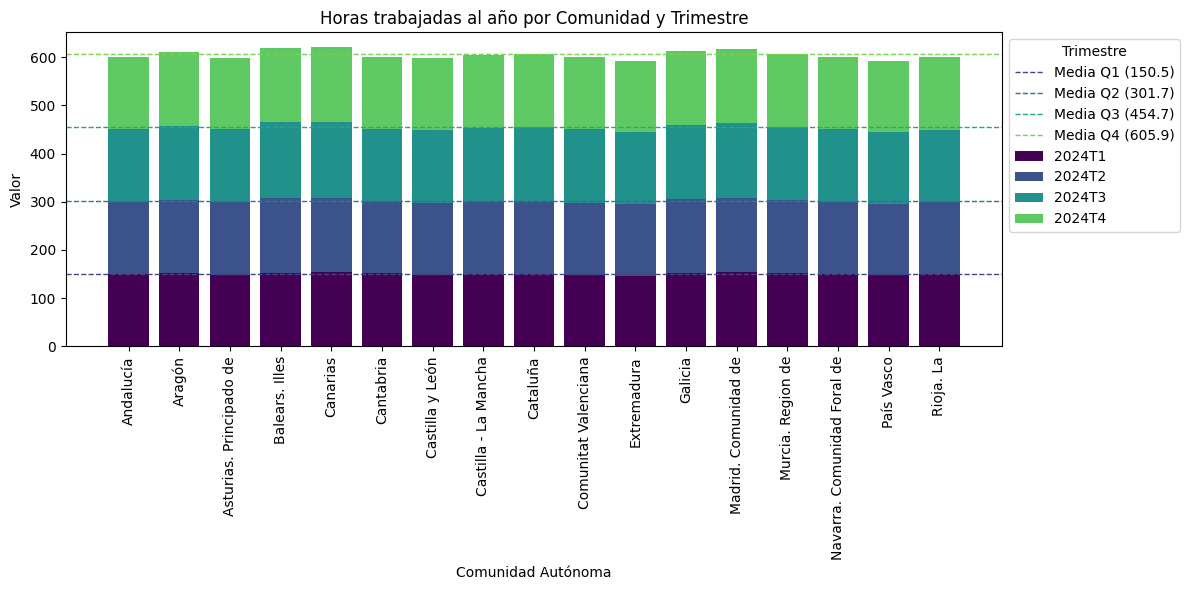

In [25]:
# Calculamos las medias acumuladas por periodos trimestrales
df_merged = pd.merge(df_workTime, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_2024T1 = (df_merged['2024T1'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_2024T2 = (df_merged['2024T2'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum() + mean_2024T1
mean_2024T3 = (df_merged['2024T3'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum() + mean_2024T2
mean_2024T4 = (df_merged['2024T4'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum() + mean_2024T3

# Ttransformamos el DataFrame a formato largo para facilitar el plot
df_workTime_melted = df_workTime.melt(id_vars='comunidad_autonoma', 
                  value_vars=['2024T4', '2024T3', '2024T2', '2024T1'],
                  var_name='Trimestre', value_name='Valor')

# Renombra los valores para mejor lectura
df_workTime_melted['Trimestre'] = df_workTime_melted['Trimestre'].map({
    '2024T1': 'Q1',
    '2024T2': 'Q2',
    '2024T3': 'Q3',
    '2024T4': 'Q4'
})

trimestres_order = ['2024T1', '2024T2', '2024T3', '2024T4']
df_workTime_melted['Trimestre'] = pd.Categorical(df_workTime_melted['Trimestre'], categories=trimestres_order, ordered=True)

# Crear una lista de comunidades autónomas
comunidades = df_workTime['comunidad_autonoma']

# Número de comunidades
n_comunidades = len(comunidades)

# Posiciones en el eje x
indices = np.arange(n_comunidades)

# Preparar la paleta viridis
cmap = plt.get_cmap('viridis')
colors = [cmap(i / len(trimestres_order)) for i in range(len(trimestres_order))]

# Crear la figura
plt.figure(figsize=(12, 6))

# Para apilar las barras, necesitamos mantener un array de bottoms
bottoms = np.zeros(n_comunidades)

# Iterar sobre los trimestres en orden
for i, trimestre in enumerate(trimestres_order):
    # Extraer los valores para cada comunidad y trimestre
    valores = []
    for comunidad in comunidades:
        valor = df_workTime.loc[df_workTime['comunidad_autonoma'] == comunidad, trimestre].values[0]
        valores.append(valor)
    # Dibujar las barras apiladas
    plt.bar(indices, valores, bottom=bottoms, color=colors[i], label=trimestre)
    # Actualizar bottoms
    bottoms += np.array(valores)

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'Q1': sns.color_palette('viridis', 4)[0],
    'Q2': sns.color_palette('viridis', 4)[1],
    'Q3': sns.color_palette('viridis', 4)[2],
    'Q4': sns.color_palette('viridis', 4)[3]
}

plt.axhline(mean_2024T1, color=colores_lineas['Q1'], linestyle='--', linewidth=1, label=f'Media Q1 ({mean_2024T1:.1f})')
plt.axhline(mean_2024T2, color=colores_lineas['Q2'], linestyle='--', linewidth=1, label=f'Media Q2 ({mean_2024T2:.1f})')
plt.axhline(mean_2024T3, color=colores_lineas['Q3'], linestyle='--', linewidth=1, label=f'Media Q3 ({mean_2024T3:.1f})')
plt.axhline(mean_2024T4, color=colores_lineas['Q4'], linestyle='--', linewidth=1, label=f'Media Q4 ({mean_2024T4:.1f})')

# Configurar etiquetas y leyenda
plt.xticks(indices, df_workTime['comunidad_autonoma'], rotation=90)
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Valor')
plt.title('Horas trabajadas al año por Comunidad y Trimestre')
plt.legend(title='Trimestre', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}09_01_horas_trabajadas.png', dpi=300, bbox_inches='tight')
plt.show()

## Salario Bruto Anual

Los datos muestran el salario bruto anual para una jornada completa, desglosado por comunidad autónoma.

In [26]:
df_salary = pd.read_csv(f'{data_basepath}salario_bruto_anual_por_comunidad.csv', sep=';')
df_salary

,comunidad_autonoma,ambos_sexos,mujeres,hombres
0,Andalucía,24041.96,21649.50,26159.02
1,Aragón,26012.71,23138.72,28789.96
2,Asturias. Principado de,26745.93,23792.42,29573.74
3,Balears. Illes,27145.79,26054.20,28155.99
4,Canarias,23096.92,22574.98,23588.70
5,Cantabria,25291.14,22564.11,27820.83
6,Castilla y León,24186.89,21773.27,26548.08
7,Castilla - La Mancha,23751.71,21312.65,25813.23
8,Cataluña,28774.55,25659.03,31878.42
9,Comunitat Valenciana,24510.34,22135.35,26683.85


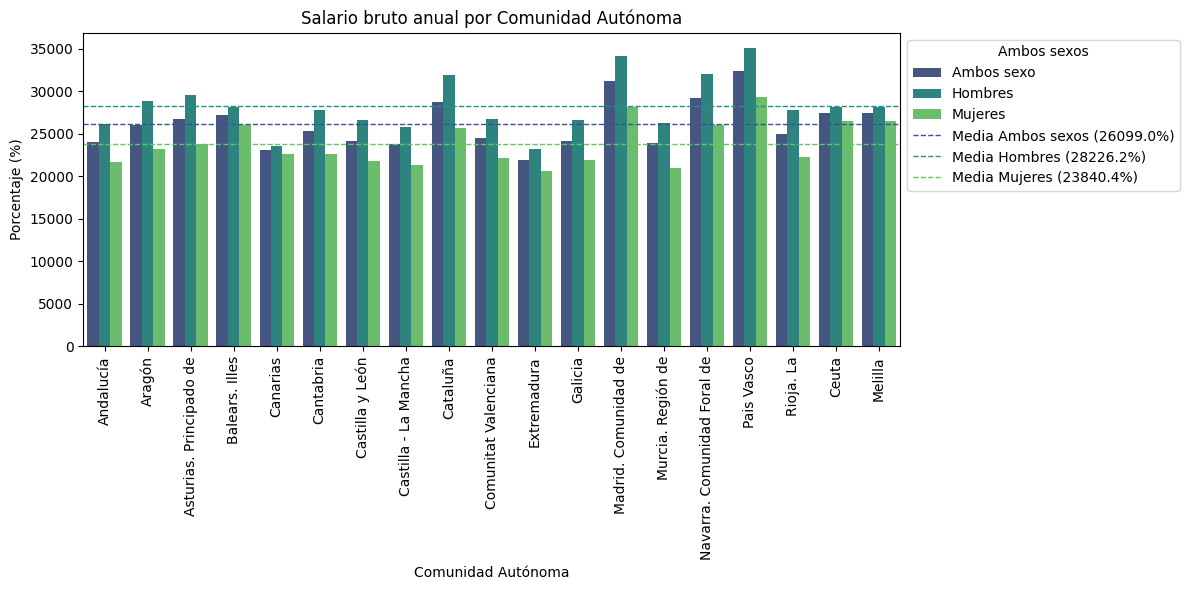

In [27]:
# # Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
# df_merged = pd.merge(df_salary, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
# mean_ambos_sexos = (df_merged['ambos_sexos'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
# mean_hombres = (df_merged['hombres'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
# mean_mujeres = (df_merged['mujeres'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()


# Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
mean_ambos_sexos = df_salary['ambos_sexos'].mean()
mean_hombres = df_salary['hombres'].mean()
mean_mujeres = df_salary['mujeres'].mean()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_cinemaAttendance_melted = df_salary.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['ambos_sexos', 'hombres', 'mujeres'],
    var_name='cine_Ambos sexos',
    value_name='Porcentaje'
)

# Renombra los valores para mejor lectura
df_cinemaAttendance_melted['cine_Ambos sexos'] = df_cinemaAttendance_melted['cine_Ambos sexos'].map({
    'ambos_sexos': 'Ambos sexo',
    'hombres': 'Hombres',
    'mujeres': 'Mujeres'
})

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'Ambos sexos': sns.color_palette('viridis', 3)[0],
    'Hombres': sns.color_palette('viridis', 3)[1],
    'Mujeres': sns.color_palette('viridis', 3)[2]
}

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_cinemaAttendance_melted,
    x='comunidad_autonoma',
    y='Porcentaje',
    hue='cine_Ambos sexos',
    palette='viridis'
)

plt.axhline(mean_ambos_sexos, color=colores_lineas['Ambos sexos'], linestyle='--', linewidth=1, label=f'Media Ambos sexos ({mean_ambos_sexos:.1f}%)')
plt.axhline(mean_hombres, color=colores_lineas['Hombres'], linestyle='--', linewidth=1, label=f'Media Hombres ({mean_hombres:.1f}%)')
plt.axhline(mean_mujeres, color=colores_lineas['Mujeres'], linestyle='--', linewidth=1, label=f'Media Mujeres ({mean_mujeres:.1f}%)')

plt.title('Salario bruto anual por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Ambos sexos', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}10_01_salario.png', dpi=300, bbox_inches='tight')
plt.show()

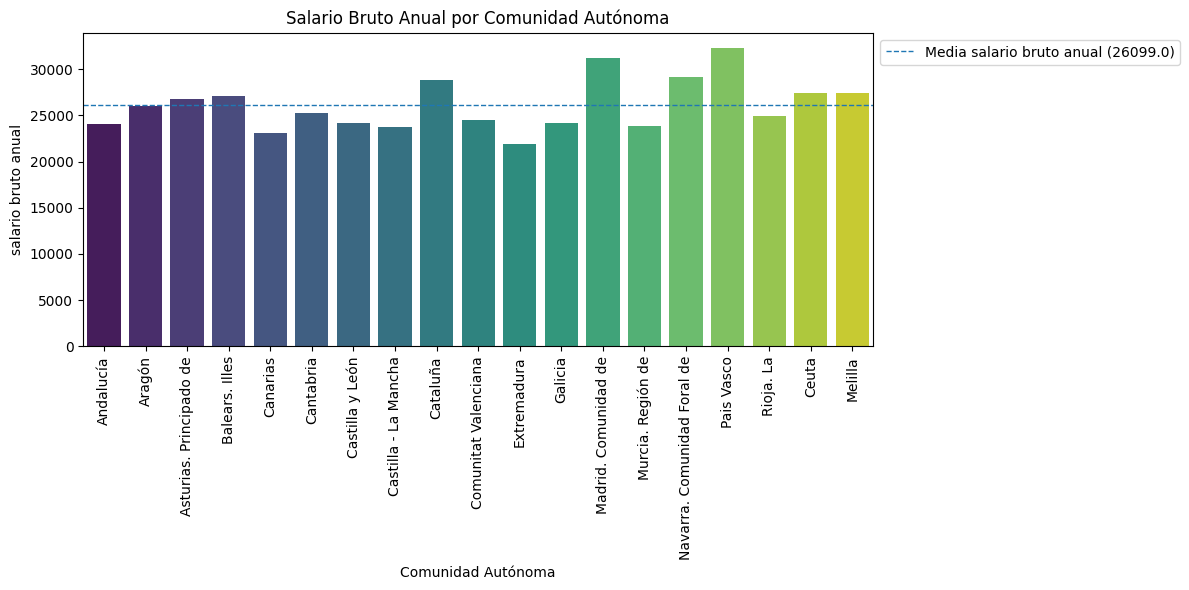

In [28]:
# Calcula las medias nacionales para cada categoría (en caso de ser valores absolutos)
mean_salary = df_salary['ambos_sexos'].mean()

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_salary,
    x='comunidad_autonoma',
    y='ambos_sexos',
    palette='viridis'
)

plt.axhline(mean_salary, linestyle='--', linewidth=1, label=f'Media salario bruto anual ({mean_salary:.1f})')

plt.title('Salario Bruto Anual por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('salario bruto anual')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}10_02_salario.png', dpi=300, bbox_inches='tight')
plt.show()

## Satisfacción servicios sanitarios

Se muestran las cifras relativas de la Encuesta Europea de Salud en España 2009.
Satisfacción con distintos servicios sanitarios (hospitales, dentistas, especialistas y medicina general) según comunidad autónoma.

In [29]:
df_healthSatisfaction = pd.read_csv(f'{data_basepath}satisfaccionSanidad_por_comunidad.csv', sep=';')
df_healthSatisfaction

,comunidad_autonoma,hospitales_muy_satisfecho/a,hospitales_satisfecho/a,hospitales_neutral,hospitales_insatisfecho/a,hospitales_muy_insatisfecho/a,dentistas_muy_satisfecho/a,dentistas_satisfecho/a,dentistas_neutral,dentistas_insatisfecho/a,...,especialistas_muy_satisfecho/a,especialistas_satisfecho/a,especialistas_neutral,especialistas_insatisfecho/a,especialistas_muy_insatisfecho/a,medGeneral_muy_satisfecho/a,medGeneral_satisfecho/a,medGeneral_neutral,medGeneral_insatisfecho/a,medGeneral_muy_insatisfecho/a
0,Andalucía,12.31,43.93,27.50,9.68,6.59,14.06,54.66,22.64,3.08,...,15.80,55.54,22.52,3.25,2.88,21.60,54.78,17.45,4.00,2.18
1,Aragón,18.60,48.58,24.77,3.88,4.16,13.82,44.81,33.43,1.60,...,19.03,51.40,20.83,4.46,4.28,46.85,41.50,8.85,1.79,1.01
2,Asturias. Principado de,17.22,56.73,17.06,6.08,2.91,16.85,65.29,13.78,2.46,...,16.64,61.01,16.47,3.87,2.02,25.39,55.47,13.11,3.59,2.45
3,Balears. Illes,15.78,46.59,24.83,7.49,5.32,11.92,49.60,33.32,3.15,...,15.27,51.25,26.38,4.92,2.18,23.26,48.42,22.37,3.94,2.01
4,Canarias,21.66,33.99,26.33,8.95,9.07,20.77,31.03,9.79,3.44,...,36.93,33.31,16.55,6.42,6.79,38.68,38.24,14.52,4.20,4.36
5,Cantabria,27.78,45.94,17.72,4.89,3.67,38.61,41.87,13.59,3.38,...,29.88,44.84,16.30,5.69,3.29,49.43,37.46,9.29,2.23,1.59
6,Castilla y León,45.68,29.04,15.62,6.85,2.81,50.65,35.34,9.23,3.44,...,47.67,33.21,12.14,5.23,1.75,56.57,30.24,8.35,3.47,1.37
7,Castilla - La Mancha,9.37,59.06,17.97,7.62,5.99,7.77,67.69,15.77,4.95,...,9.96,66.16,15.90,4.89,3.09,15.62,67.70,9.39,3.84,3.45
8,Cataluña,17.40,49.49,19.00,8.45,5.66,19.77,62.38,11.75,3.68,...,23.71,59.69,11.51,3.07,2.02,29.32,56.03,10.02,3.10,1.53
9,Comunitat Valenciana,16.24,46.21,22.44,8.72,6.39,16.69,58.64,14.33,5.44,...,18.87,58.34,14.81,4.61,3.37,31.82,50.26,12.69,2.33,2.90


### Hospitales

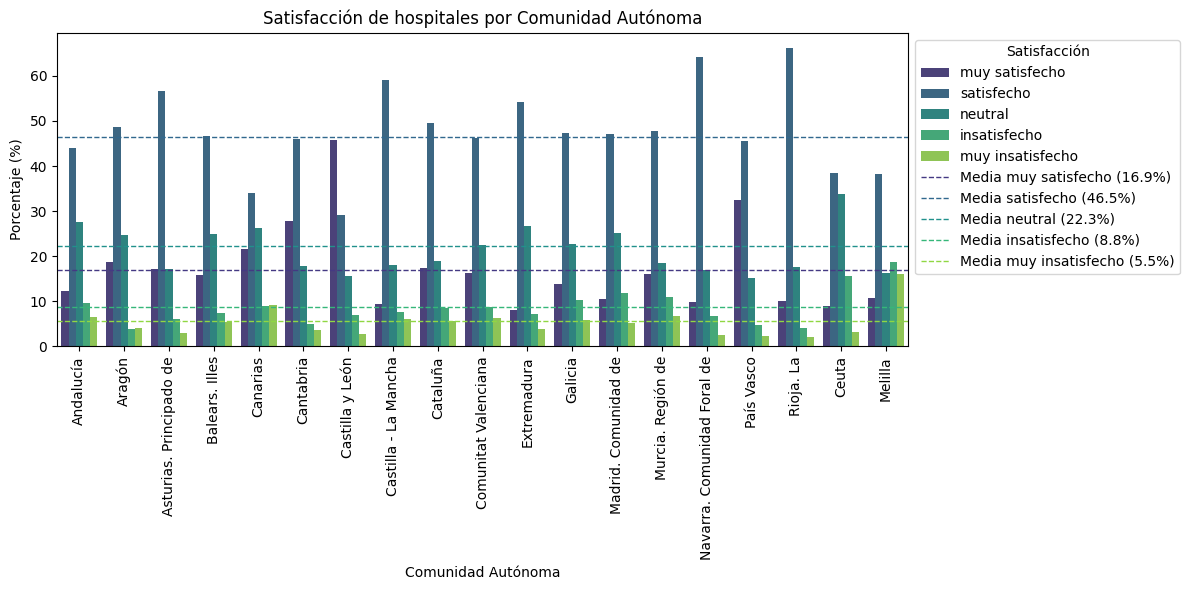

In [30]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_healthSatisfaction, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_hospitales_muy_satisfecho = (df_merged['hospitales_muy_satisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_hospitales_satisfecho = (df_merged['hospitales_satisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_hospitales_neutral = (df_merged['hospitales_neutral'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_hospitales_insatisfecho = (df_merged['hospitales_insatisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_hospitales_muy_insatisfecho = (df_merged['hospitales_muy_insatisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_healthSatisfaction_melted = df_healthSatisfaction.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['hospitales_muy_satisfecho/a',
                'hospitales_satisfecho/a',
                'hospitales_neutral',
                'hospitales_insatisfecho/a',
                'hospitales_muy_insatisfecho/a'
                ],
    var_name='hospitales_satisfaccion',
    value_name='porcentaje'
)

# Renombra los valores para mejor lectura
df_healthSatisfaction_melted['hospitales_satisfaccion'] = df_healthSatisfaction_melted['hospitales_satisfaccion'].map({
    'hospitales_muy_satisfecho/a': 'muy satisfecho',
    'hospitales_satisfecho/a': 'satisfecho',
    'hospitales_neutral': 'neutral',
    'hospitales_insatisfecho/a': 'insatisfecho',
    'hospitales_muy_insatisfecho/a': 'muy insatisfecho'
})

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'muy satisfecho': sns.color_palette('viridis', 5)[0],
    'satisfecho': sns.color_palette('viridis', 5)[1],
    'neutral': sns.color_palette('viridis', 5)[2],
    'insatisfecho': sns.color_palette('viridis', 5)[3],
    'muy insatisfecho': sns.color_palette('viridis', 5)[4]
}

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_healthSatisfaction_melted,
    x='comunidad_autonoma',
    y='porcentaje',
    hue='hospitales_satisfaccion',
    palette='viridis'
)

plt.axhline(mean_hospitales_muy_satisfecho, color=colores_lineas['muy satisfecho'], linestyle='--', linewidth=1, label=f'Media muy satisfecho ({mean_hospitales_muy_satisfecho:.1f}%)')
plt.axhline(mean_hospitales_satisfecho, color=colores_lineas['satisfecho'], linestyle='--', linewidth=1, label=f'Media satisfecho ({mean_hospitales_satisfecho:.1f}%)')
plt.axhline(mean_hospitales_neutral, color=colores_lineas['neutral'], linestyle='--', linewidth=1, label=f'Media neutral ({mean_hospitales_neutral:.1f}%)')
plt.axhline(mean_hospitales_insatisfecho, color=colores_lineas['insatisfecho'], linestyle='--', linewidth=1, label=f'Media insatisfecho ({mean_hospitales_insatisfecho:.1f}%)')
plt.axhline(mean_hospitales_muy_insatisfecho, color=colores_lineas['muy insatisfecho'], linestyle='--', linewidth=1, label=f'Media muy insatisfecho ({mean_hospitales_muy_insatisfecho:.1f}%)')

plt.title('Satisfacción de hospitales por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Satisfacción', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}11_01_sanidad.png', dpi=300, bbox_inches='tight')
plt.show()

### Dentistas

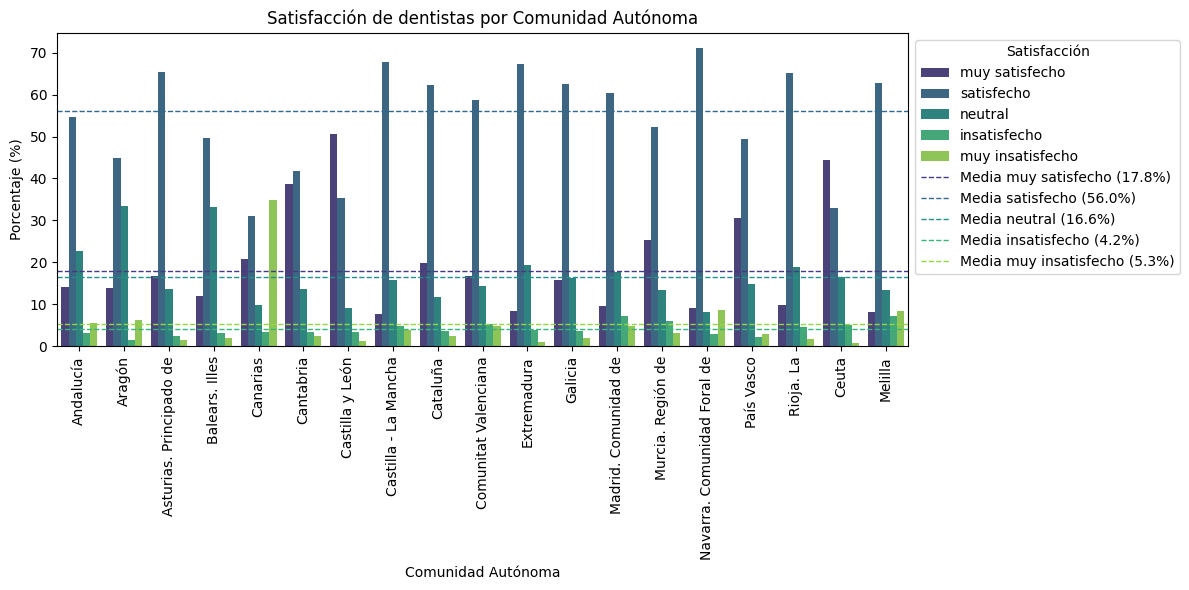

In [31]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_healthSatisfaction, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_dentistas_muy_satisfecho = (df_merged['dentistas_muy_satisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_dentistas_satisfecho = (df_merged['dentistas_satisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_dentistas_neutral = (df_merged['dentistas_neutral'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_dentistas_insatisfecho = (df_merged['dentistas_insatisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_dentistas_muy_insatisfecho = (df_merged['dentistas_muy_insatisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_healthSatisfaction_melted = df_healthSatisfaction.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['dentistas_muy_satisfecho/a',
                'dentistas_satisfecho/a',
                'dentistas_neutral',
                'dentistas_insatisfecho/a',
                'dentistas_muy_insatisfecho/a'
                ],
    var_name='dentistas_satisfaccion',
    value_name='porcentaje'
)

# Renombra los valores para mejor lectura
df_healthSatisfaction_melted['dentistas_satisfaccion'] = df_healthSatisfaction_melted['dentistas_satisfaccion'].map({
    'dentistas_muy_satisfecho/a': 'muy satisfecho',
    'dentistas_satisfecho/a': 'satisfecho',
    'dentistas_neutral': 'neutral',
    'dentistas_insatisfecho/a': 'insatisfecho',
    'dentistas_muy_insatisfecho/a': 'muy insatisfecho'
})

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'muy satisfecho': sns.color_palette('viridis', 5)[0],
    'satisfecho': sns.color_palette('viridis', 5)[1],
    'neutral': sns.color_palette('viridis', 5)[2],
    'insatisfecho': sns.color_palette('viridis', 5)[3],
    'muy insatisfecho': sns.color_palette('viridis', 5)[4]
}

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_healthSatisfaction_melted,
    x='comunidad_autonoma',
    y='porcentaje',
    hue='dentistas_satisfaccion',
    palette='viridis'
)

plt.axhline(mean_dentistas_muy_satisfecho, color=colores_lineas['muy satisfecho'], linestyle='--', linewidth=1, label=f'Media muy satisfecho ({mean_dentistas_muy_satisfecho:.1f}%)')
plt.axhline(mean_dentistas_satisfecho, color=colores_lineas['satisfecho'], linestyle='--', linewidth=1, label=f'Media satisfecho ({mean_dentistas_satisfecho:.1f}%)')
plt.axhline(mean_dentistas_neutral, color=colores_lineas['neutral'], linestyle='--', linewidth=1, label=f'Media neutral ({mean_dentistas_neutral:.1f}%)')
plt.axhline(mean_dentistas_insatisfecho, color=colores_lineas['insatisfecho'], linestyle='--', linewidth=1, label=f'Media insatisfecho ({mean_dentistas_insatisfecho:.1f}%)')
plt.axhline(mean_dentistas_muy_insatisfecho, color=colores_lineas['muy insatisfecho'], linestyle='--', linewidth=1, label=f'Media muy insatisfecho ({mean_dentistas_muy_insatisfecho:.1f}%)')

plt.title('Satisfacción de dentistas por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Satisfacción', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}11_02_sanidad.png', dpi=300, bbox_inches='tight')
plt.show()

### Especialistas

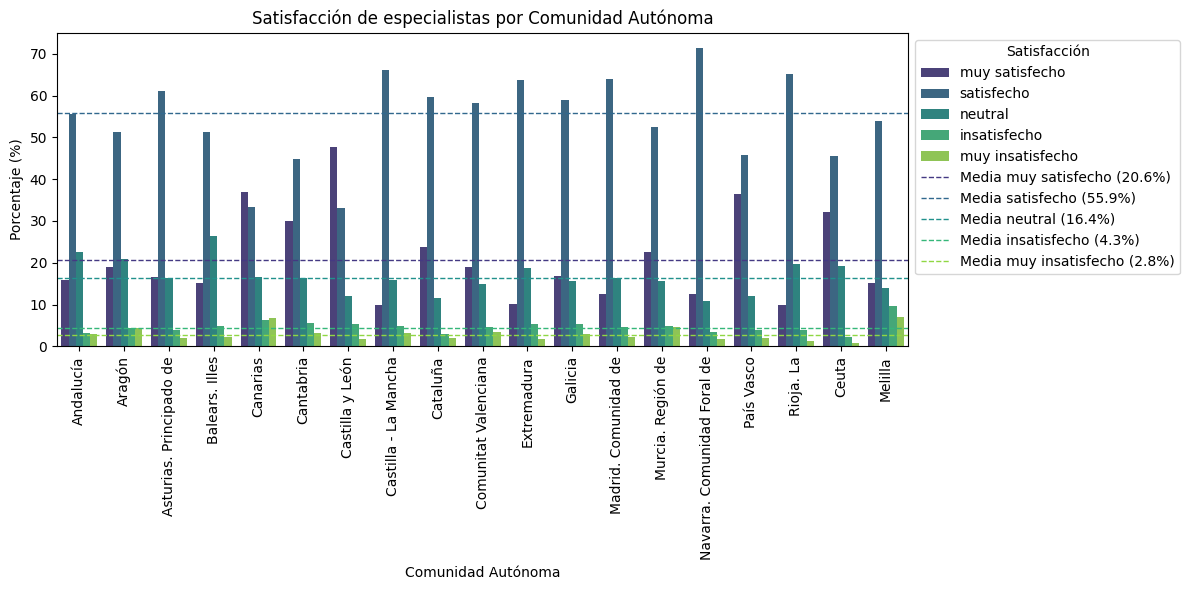

In [32]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_healthSatisfaction, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_especialistas_muy_satisfecho = (df_merged['especialistas_muy_satisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_especialistas_satisfecho = (df_merged['especialistas_satisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_especialistas_neutral = (df_merged['especialistas_neutral'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_especialistas_insatisfecho = (df_merged['especialistas_insatisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_especialistas_muy_insatisfecho = (df_merged['especialistas_muy_insatisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_healthSatisfaction_melted = df_healthSatisfaction.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['especialistas_muy_satisfecho/a',
                'especialistas_satisfecho/a',
                'especialistas_neutral',
                'especialistas_insatisfecho/a',
                'especialistas_muy_insatisfecho/a'
                ],
    var_name='especialistas_satisfaccion',
    value_name='porcentaje'
)

# Renombra los valores para mejor lectura
df_healthSatisfaction_melted['especialistas_satisfaccion'] = df_healthSatisfaction_melted['especialistas_satisfaccion'].map({
    'especialistas_muy_satisfecho/a': 'muy satisfecho',
    'especialistas_satisfecho/a': 'satisfecho',
    'especialistas_neutral': 'neutral',
    'especialistas_insatisfecho/a': 'insatisfecho',
    'especialistas_muy_insatisfecho/a': 'muy insatisfecho'
})

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'muy satisfecho': sns.color_palette('viridis', 5)[0],
    'satisfecho': sns.color_palette('viridis', 5)[1],
    'neutral': sns.color_palette('viridis', 5)[2],
    'insatisfecho': sns.color_palette('viridis', 5)[3],
    'muy insatisfecho': sns.color_palette('viridis', 5)[4]
}

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_healthSatisfaction_melted,
    x='comunidad_autonoma',
    y='porcentaje',
    hue='especialistas_satisfaccion',
    palette='viridis'
)

plt.axhline(mean_especialistas_muy_satisfecho, color=colores_lineas['muy satisfecho'], linestyle='--', linewidth=1, label=f'Media muy satisfecho ({mean_especialistas_muy_satisfecho:.1f}%)')
plt.axhline(mean_especialistas_satisfecho, color=colores_lineas['satisfecho'], linestyle='--', linewidth=1, label=f'Media satisfecho ({mean_especialistas_satisfecho:.1f}%)')
plt.axhline(mean_especialistas_neutral, color=colores_lineas['neutral'], linestyle='--', linewidth=1, label=f'Media neutral ({mean_especialistas_neutral:.1f}%)')
plt.axhline(mean_especialistas_insatisfecho, color=colores_lineas['insatisfecho'], linestyle='--', linewidth=1, label=f'Media insatisfecho ({mean_especialistas_insatisfecho:.1f}%)')
plt.axhline(mean_especialistas_muy_insatisfecho, color=colores_lineas['muy insatisfecho'], linestyle='--', linewidth=1, label=f'Media muy insatisfecho ({mean_especialistas_muy_insatisfecho:.1f}%)')

plt.title('Satisfacción de especialistas por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Satisfacción', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}11_03_sanidad.png', dpi=300, bbox_inches='tight')
plt.show()

### Medicina General

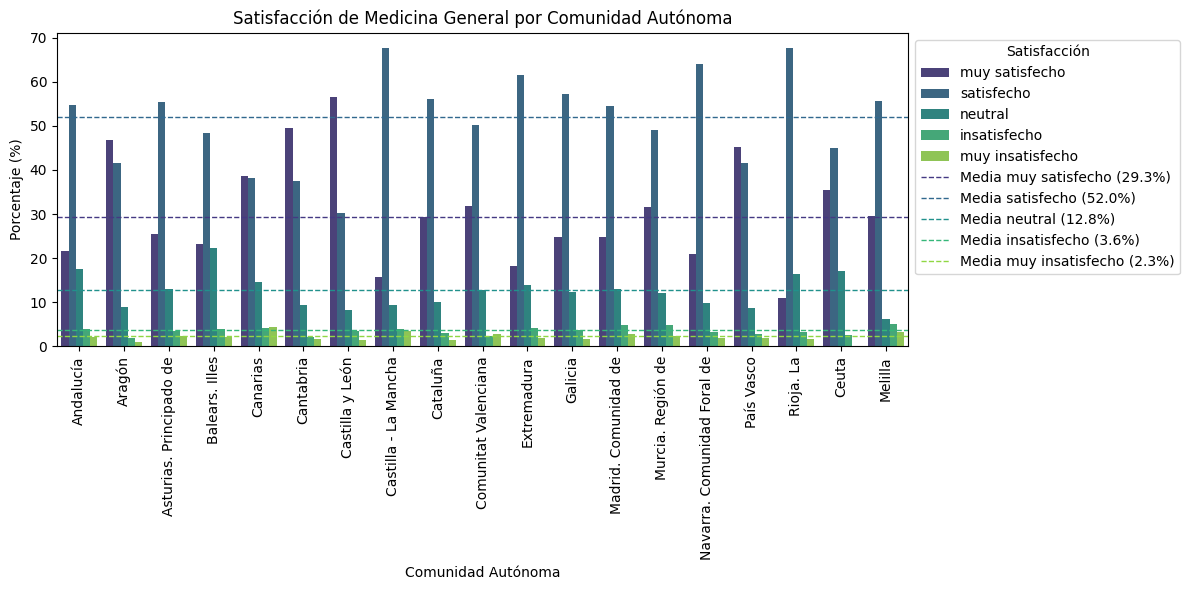

In [33]:
# Incluye la columna poblacion para calcular la media en función de la población de cada comunidad autónoma (en caso de que los valores sean porcentajes)
df_merged = pd.merge(df_healthSatisfaction, df_population[['comunidad_autonoma', 'poblacion']], on='comunidad_autonoma', how='left')
mean_medGeneral_muy_satisfecho = (df_merged['medGeneral_muy_satisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_medGeneral_satisfecho = (df_merged['medGeneral_satisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_medGeneral_neutral = (df_merged['medGeneral_neutral'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_medGeneral_insatisfecho = (df_merged['medGeneral_insatisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()
mean_medGeneral_muy_insatisfecho = (df_merged['medGeneral_muy_insatisfecho/a'] * df_merged['poblacion']).sum() / df_merged['poblacion'].sum()

# Convierte el dataframe inicial en una única columna, con los valores unificados para su representación
df_healthSatisfaction_melted = df_healthSatisfaction.melt(
    id_vars=['comunidad_autonoma'],
    value_vars=['medGeneral_muy_satisfecho/a',
                'medGeneral_satisfecho/a',
                'medGeneral_neutral',
                'medGeneral_insatisfecho/a',
                'medGeneral_muy_insatisfecho/a'
                ],
    var_name='medGeneral_satisfaccion',
    value_name='porcentaje'
)

# Renombra los valores para mejor lectura
df_healthSatisfaction_melted['medGeneral_satisfaccion'] = df_healthSatisfaction_melted['medGeneral_satisfaccion'].map({
    'medGeneral_muy_satisfecho/a': 'muy satisfecho',
    'medGeneral_satisfecho/a': 'satisfecho',
    'medGeneral_neutral': 'neutral',
    'medGeneral_insatisfecho/a': 'insatisfecho',
    'medGeneral_muy_insatisfecho/a': 'muy insatisfecho'
})

# Colores para las líneas (usando los mismos que en la gráfica de barras)
colores_lineas = {
    'muy satisfecho': sns.color_palette('viridis', 5)[0],
    'satisfecho': sns.color_palette('viridis', 5)[1],
    'neutral': sns.color_palette('viridis', 5)[2],
    'insatisfecho': sns.color_palette('viridis', 5)[3],
    'muy insatisfecho': sns.color_palette('viridis', 5)[4]
}

# Crea un gráfico de barras para visualizar el porcentaje por comunidad autónoma
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_healthSatisfaction_melted,
    x='comunidad_autonoma',
    y='porcentaje',
    hue='medGeneral_satisfaccion',
    palette='viridis'
)

plt.axhline(mean_medGeneral_muy_satisfecho, color=colores_lineas['muy satisfecho'], linestyle='--', linewidth=1, label=f'Media muy satisfecho ({mean_medGeneral_muy_satisfecho:.1f}%)')
plt.axhline(mean_medGeneral_satisfecho, color=colores_lineas['satisfecho'], linestyle='--', linewidth=1, label=f'Media satisfecho ({mean_medGeneral_satisfecho:.1f}%)')
plt.axhline(mean_medGeneral_neutral, color=colores_lineas['neutral'], linestyle='--', linewidth=1, label=f'Media neutral ({mean_medGeneral_neutral:.1f}%)')
plt.axhline(mean_medGeneral_insatisfecho, color=colores_lineas['insatisfecho'], linestyle='--', linewidth=1, label=f'Media insatisfecho ({mean_medGeneral_insatisfecho:.1f}%)')
plt.axhline(mean_medGeneral_muy_insatisfecho, color=colores_lineas['muy insatisfecho'], linestyle='--', linewidth=1, label=f'Media muy insatisfecho ({mean_medGeneral_muy_insatisfecho:.1f}%)')

plt.title('Satisfacción de Medicina General por Comunidad Autónoma')
plt.xlabel('Comunidad Autónoma')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=90)
plt.legend(title='Satisfacción', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{img_basepath}11_04_sanidad.png', dpi=300, bbox_inches='tight')
plt.show()